In [2]:
import yfinance as yf 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
#%pip install statsmodels
import statsmodels.api as sm 
import os

print(" your script is running in this folder", os.getcwd())
print("all files without full path are saved here \n")


 your script is running in this folder c:\Users\izadi\AppData\Local\Programs\Microsoft VS Code
all files without full path are saved here 



In [3]:
TICKERS = {
    'Lufthansa' : 'LHA.DE',
    'DAX' : '^GDAXI',
    'Oil_Brent' : 'BZ=F',
    'EURUSD' : 'EURUSD=X'
}

In [4]:
INDUSTRY_PEERS = ['AF.PA', 'IAG.L', 'RYA.IR']

In [5]:
START_DATE = '2025-01-01'
END_DATE = '2026-03-01'

os.makedirs('output', exist_ok = True)
print("downloading data from yahoo finance ")

downloading data from yahoo finance 


In [6]:
data = yf.download(list(TICKERS.values()) + INDUSTRY_PEERS,
                   start= START_DATE, end = END_DATE,
                   progress = False) ['Close']

In [7]:
data.columns = list(TICKERS.keys()) + INDUSTRY_PEERS
print(f"Data shape: {data.shape}")
print(data.tail())

Data shape: (299, 7)
            Lufthansa        DAX  Oil_Brent      EURUSD  AF.PA  IAG.L  \
Date                                                                    
2026-02-23     13.140  71.489998   1.183474  429.899994  9.180  26.58   
2026-02-24     12.715  70.769997   1.179384  433.500000  9.138  27.02   
2026-02-25     12.870  70.849998   1.177523  446.100006  9.184  27.48   
2026-02-26     13.140  70.750000   1.181516  457.299988  9.426  28.10   
2026-02-27     12.300  72.480003   1.180303  423.700012  9.088  27.42   

                  RYA.IR  
Date                      
2026-02-23  24991.970703  
2026-02-24  24986.250000  
2026-02-25  25175.939453  
2026-02-26  25289.019531  
2026-02-27  25284.259766  


In [8]:
industry_prices = data[INDUSTRY_PEERS].copy()
industry_norm = (industry_prices / industry_prices.iloc[0]) * 100
industry_index = industry_norm.mean(axis = 1)
industry_index_name = "Airline_Industry_Index"

data['Airline_Industry_Index'] = industry_index

In [9]:
plt.figure(figsize= (14,8))
norm_data = (data[['Lufthansa', 'DAX', 'Airline_Industry_Index']] / 
             data[['Lufthansa', 'DAX', 'Airline_Industry_Index']].iloc[0]) * 100


norm_data.plot(ax=plt.gca(), linewidth = 2.5)
plt.title('lufthansa vs DAX vs European Airline Industry (Normalaized to 100)')
plt.ylabel('Index (Start = 100)')
plt.grid(True, alpha = 0.3)
plt.legend(['Lufthansa (LHA.DE)', 'DAX (^GDAXI)' 'Airline Industry (FA.PA + IAG.L + RYA.IR avg)'])
plt.savefig('output/normalized_prices.png', dpi = 300, bbox_inches = 'tight')
plt.close()
print('saved: normalized_prices.png')


saved: normalized_prices.png


In [10]:
returns = data.pct_change().dropna()

print("\n Annualized Returns & Volatility (last 5+ years)")
for col in ['Lufthansa', 'DAX', 'Airline_Industry_Index', 'Oil_Brent']:
    ret = returns[col].mean()*252
    vol = returns[col].std() * np.sqrt(252)
    print(f"{col:25}  | Return: {ret*100:6.2f}% | Vol: {vol*100:6.2f}%")


 Annualized Returns & Volatility (last 5+ years)
Lufthansa                  | Return:  49.92% | Vol:  55.20%
DAX                        | Return:   0.34% | Vol:  29.20%
Airline_Industry_Index     | Return:  34.33% | Vol:  29.48%
Oil_Brent                  | Return:  11.40% | Vol:   7.79%


C:\Users\izadi\AppData\Local\Temp\ipykernel_13592\3934456375.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change().dropna()


saved: correlation_heatmap.png


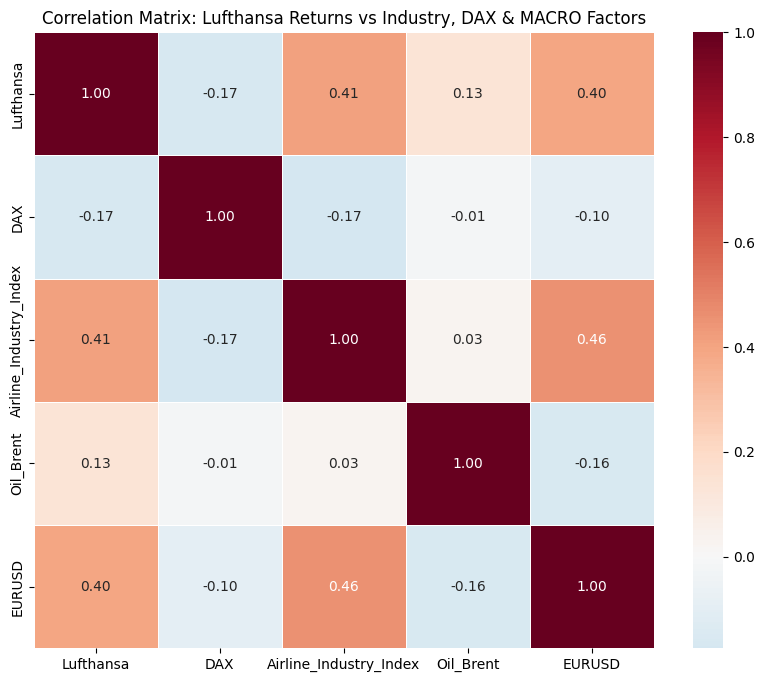

In [11]:
corr = returns[['Lufthansa', 'DAX', 'Airline_Industry_Index', 'Oil_Brent', 'EURUSD']].corr()
plt.figure(figsize = (10,8))
sns.heatmap(corr, annot=True, cmap = 'RdBu_r', center = 0, fmt= '.2f', linewidths= 0.5)
plt.title('Correlation Matrix: Lufthansa Returns vs Industry, DAX & MACRO Factors')
plt.savefig('output/correlation_heatmap.png', dpi = 300, bbox_inches = "tight")
plt.close
print("saved: correlation_heatmap.png")

In [12]:
oil_corr = corr.loc['Lufthansa', 'Oil_Brent']
print(f"Lufthansa correlation with Brent Oil: {oil_corr: .3f} negative = higher fuel costs hurt profits")

Lufthansa correlation with Brent Oil:  0.134 negative = higher fuel costs hurt profits


In [13]:
def calculate_beta(asset_returns , benchmark_returns):
    cov = np.cov(asset_returns, benchmark_returns)[0][1]
    var_bench = np.var(benchmark_returns)
    return cov / var_bench

beta_dax = calculate_beta(returns['Lufthansa'], returns['DAX'])
beta_industry = calculate_beta(returns['Lufthansa'], returns ['Airline_Industry_Index'])

print(f" \n Beta Lufthansa vs DAX: {beta_dax: .2f} (market_sensitivity)")
print(f" Beta Lufthansa vs Airline Industry: {beta_industry: .2f}")


 
 Beta Lufthansa vs DAX: -0.31 (market_sensitivity)
 Beta Lufthansa vs Airline Industry:  0.77


In [14]:
x = returns[['DAX', 'Oil_Brent', 'EURUSD']]
x = sm.add_constant(x)
y = returns['Lufthansa']


model = sm.OLS(y, x).fit()
print("\n Macro Regression Results")
print(model.summary)


with open('output/regression_summary.txt', 'w') as f:
    f.write(model.summary().as_text())


print("saved : regression_summary.txt")


 Macro Regression Results
<bound method RegressionResults.summary of <statsmodels.regression.linear_model.OLSResults object at 0x00000246AD10E5D0>>
saved : regression_summary.txt


In [15]:
import os 
filename = "regression_summary.txt"
full_path = os.path.abspath(filename)
print(f"Full path to {filename}:")
print(full_path)

Full path to regression_summary.txt:
c:\Users\izadi\AppData\Local\Programs\Microsoft VS Code\regression_summary.txt


In [16]:
if os.path.exists(full_path):
    print(" File exists")
else: print("File Not found")

File Not found
